In [1]:
import cv2
import numpy as np

In [2]:
def absSumDiffImage(img1, img2):
    return np.sum(np.abs(img1-img2))

Intermediate step 1

In [3]:
img_left = np.int16(cv2.imread("nose_left.png",cv2.IMREAD_GRAYSCALE))
img_right = np.int16(cv2.imread("nose_right.png",cv2.IMREAD_GRAYSCALE))


print(absSumDiffImage(img_left,img_right))

7657


Intermediate step 2

In [4]:
paths = ["nose1.png","nose2.png","nose3.png"]
difs = [0,0,0]

for i in range(len(paths)):
    img_p = np.int16(cv2.imread(paths[i] , cv2.IMREAD_GRAYSCALE))
    dif = absSumDiffImage(img_left,img_p)
    print(f"With image: {i+1} abs dif is: {dif}") # +1 is conversion from 0 index
    difs[i] = dif

print("Best fit is at" , np.argmin(difs) +1) # +1 is conversion from 0 index

With image: 1 abs dif is: 1361
With image: 2 abs dif is: 119
With image: 3 abs dif is: 1490
Best fit is at 2


Intermediate step 3:

In [5]:
def findMatch(img_slice, template):
    span = img_slice.shape[1]
    difs_span = np.zeros(span)

    #Assuming height is always 7, with 4 as middle pixel
    for i in range(span):
        #cannot use the first or last i:
        if i < 3 or i > span -4:
            difs_span[i] = np.inf
            continue

        img_current = img_slice[:,i-3:i+4]
        difs_span[i] = float(absSumDiffImage(img_current, template))

    return np.argmin(difs_span) 


img_nose_span = np.int16(cv2.imread("nose_span.png",cv2.IMREAD_GRAYSCALE))
print("Best fit is at pixel" , findMatch(img_nose_span, img_left)) 

Best fit is at pixel 135


Challange

In [20]:
tsukuba_left = np.int16(cv2.imread("tsukuba_left.png", cv2.IMREAD_GRAYSCALE))
tsukuba_right = np.int16(cv2.imread("tsukuba_right.png", cv2.IMREAD_GRAYSCALE))

#Im gonna make a movement map and then store where I find the template match
movement_map = np.zeros_like(tsukuba_left)

rows = tsukuba_left.shape[0]
columns = tsukuba_right.shape[1]

In [21]:
for i in range(rows):
    if i%5 == 0:
        print("Rows are", int((i/rows)*100),r"% finished")
    for j in range(columns):
        if (i < 3 or i > rows -4) or (j < 3 or j > columns -4):
            #We assume no movement on the edges since we cannot compute it
            movement_map[i,j] = 0
            continue

        current_template = tsukuba_left[i-3:i+4,j-3:j+4]
        movement_map[i,j] = findMatch(tsukuba_right[i-3:i+4,:],current_template) - j
        

Rows are 0 % finished
Rows are 1 % finished
Rows are 3 % finished
Rows are 5 % finished
Rows are 6 % finished
Rows are 8 % finished
Rows are 10 % finished
Rows are 12 % finished
Rows are 13 % finished
Rows are 15 % finished
Rows are 17 % finished
Rows are 19 % finished
Rows are 20 % finished
Rows are 22 % finished
Rows are 24 % finished
Rows are 26 % finished
Rows are 27 % finished
Rows are 29 % finished
Rows are 31 % finished
Rows are 32 % finished
Rows are 34 % finished
Rows are 36 % finished
Rows are 38 % finished
Rows are 39 % finished
Rows are 41 % finished
Rows are 43 % finished
Rows are 45 % finished
Rows are 46 % finished
Rows are 48 % finished
Rows are 50 % finished
Rows are 52 % finished
Rows are 53 % finished
Rows are 55 % finished
Rows are 57 % finished
Rows are 59 % finished
Rows are 60 % finished
Rows are 62 % finished
Rows are 64 % finished
Rows are 65 % finished
Rows are 67 % finished
Rows are 69 % finished
Rows are 71 % finished
Rows are 72 % finished
Rows are 74 % fin

In [14]:
import matplotlib.pyplot as plt

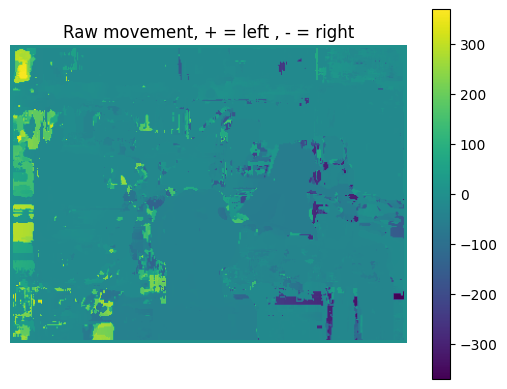

In [31]:
#Can visualise it a bit

plt.imshow(movement_map, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Raw movement, + = left , - = right")
plt.show()

Average movement is: -21.569498697916668


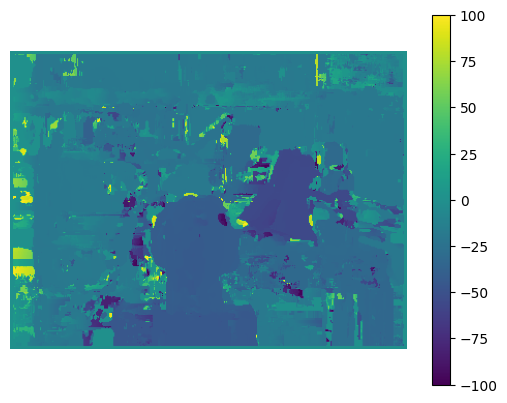

In [ ]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 100) | (movement_map_copy < -100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Raw movement, clipped to +- 100")
plt.show()

Average movement is: 10.69333224826389


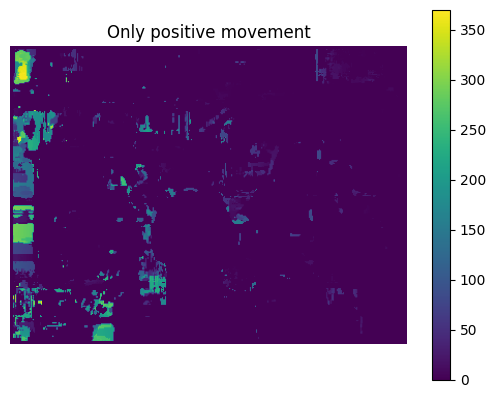

In [33]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy < 0)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only positive movement")
plt.show()

Average movement is: -28.792625144675927


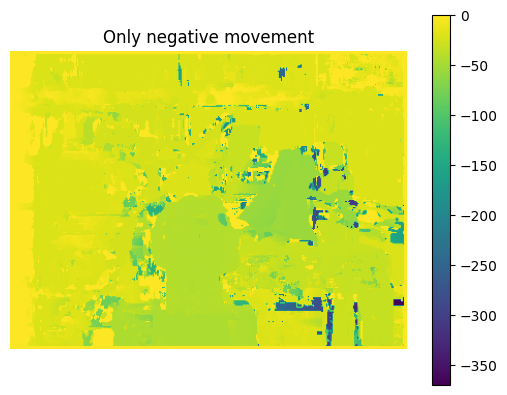

In [34]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 0)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only negative movement")
plt.show()

Average movement is: 1.9001645688657407


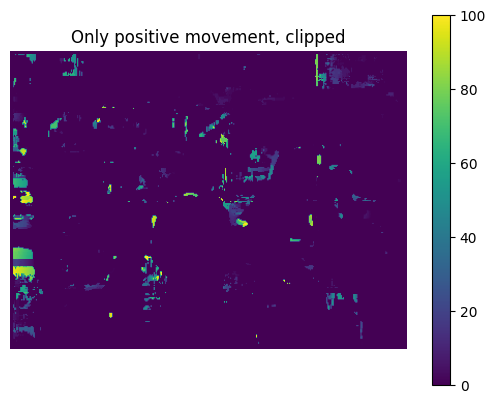

In [39]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy < 0) | (movement_map_copy > 100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only positive movement, clipped")
plt.show()

Average movement is: -23.46966326678241


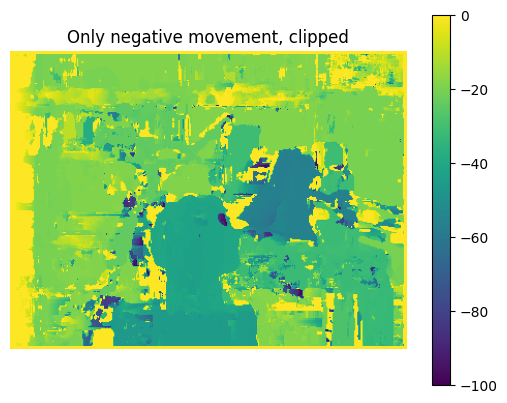

In [41]:
movement_map_copy = movement_map.copy()
#Clipping because movement more than 100 is for sure noise and i want to reduce the scala
movement_map_copy[(movement_map_copy > 0) | (movement_map_copy < -100)] = 0

print("Average movement is:", np.mean(movement_map_copy))
plt.imshow(movement_map_copy, cmap='viridis')
plt.axis("off")
plt.colorbar()
plt.title("Only negative movement, clipped")
plt.show()